In [1]:
! pip install opencxr

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencxr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 33.2 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=f6c7a05b7490860f59266990fe7db5d5f82db11a41ce61d7a648badcdc140c99
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


### Muntatge de Google Drive a Colab
Aquesta línia connecta **Google Drive** amb el entorn de **Google Colab**, creant la carpeta `/content/drive`.  



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Conversió massiva de MHA a PNG (amb correcció d’orientació)
Aquest script recorre totes les imatges **.mha** d’una carpeta i les converteix a format **.png**.  
Per cada imatge:

- La llegeix amb `read_file()` (OpenCXR).
- La **normalitza** a rang **[0,255]** per guardar-la com a imatge estàndard.
- Aplica una **correcció d’orientació** (rotació + flip) per deixar la RX ben alineada.
- Desa el resultat en PNG amb `cv2.imwrite()`.

A més, mostra una barra de progrés amb `tqdm` i imprimeix un resum final amb el temps total.


In [ ]:
import os
import numpy as np
import cv2
from opencxr.utils.file_io import read_file
from tqdm import tqdm
import time

# ===============================
# CONFIGURACIÓN
# ===============================
INPUT_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images"
OUTPUT_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images"
AUG_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ===============================
# LISTA DE ARCHIVOS MHA
# ===============================
mha_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(".mha")]
total_files = len(mha_files)

print(f"Imágenes MHA encontradas: {total_files}")
print(f"Guardando PNG corregidos en: {OUTPUT_DIR}\n")

start_time = time.time()

# ===============================
# PROCESAR TODAS LAS MHA
# ===============================
for i, fname in enumerate(tqdm(mha_files, desc="Convirtiendo MHA a PNG")):
    in_path = os.path.join(INPUT_DIR, fname)
    out_path = os.path.join(OUTPUT_DIR, fname.replace(".mha", ".png"))

    # Leer MHA
    img_np, _, _ = read_file(in_path)

    # Normalización [0,255]
    img = img_np.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = (img * 255).astype(np.uint8)

    # Corrección de orientación (OpenCXR)
    img = np.rot90(img, k=3)
    img = np.fliplr(img)

    # Guardar PNG (OpenCV)
    cv2.imwrite(out_path, img)

    if (i + 1) % 50 == 0:
        print(f"Procesadas {i+1}/{total_files} imágenes...")

elapsed = time.time() - start_time
print("\n==============================")
print("PROCESO COMPLETADO")
print(f"Total imágenes convertidas: {total_files}")
print(f"Tiempo total: {elapsed:.2f} segundos")
print("==============================")


Imágenes MHA encontradas: 4882
Guardando PNG corregidos en: /content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images1



Convirtiendo MHA a PNG:   1%|          | 48/4882 [01:31<2:23:17,  1.78s/it]

### Definició de rutes del dataset NODE21
Aquest bloc defineix les rutes principals del dataset ja processat:

- **`PATH_IMAGES`** apunta a la carpeta on hi ha les imatges (PNG) del dataset.
- **`PATH_METADATA`** apunta al fitxer **CSV** amb les anotacions i informació de cada imatge (labels i bounding boxes).

Finalment, imprimeix les dues rutes per comprovar que són correctes abans de carregar dades.


In [ ]:
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata.csv"
#PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/metadata_balanced.csv"

print(PATH_IMAGES)
print(PATH_METADATA)

### Càrrega del metadata i creació de la ruta completa d’imatge
Aquest bloc:

- Carrega el fitxer **CSV** de metadata amb `pandas`.
- Afegeix una nova columna **`file_path`** construint la ruta completa cap al fitxer **PNG** (substituint `.mha` per `.png`).
- Mostra les primeres files per validar que tot està bé (`df.head()`).
- Calcula quantes mostres hi ha de cada classe:
  - **Negatius** (`label = 0`)
  - **Positius** (`label = 1`)


In [ ]:
import pandas as pd
import os

df = pd.read_csv(PATH_METADATA)

df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

df.head()

num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("Negativos:", num_neg)
print("Positivos:", num_pos)


### Verificació visual d’una bounding box sobre una imatge positiva
Aquest codi selecciona una mostra **positiva** (`label = 1`), carrega la seva imatge **PNG** i dibuixa a sobre la **bounding box** del nòdul.

- Llegeix la primera fila positiva del dataframe.
- Converteix `x, y, width, height` a coordenades **(x1, y1, x2, y2)**.
- Dibuixa el rectangle en verd sobre la imatge.
- Mostra la imatge per confirmar que la bbox està ben alineada.


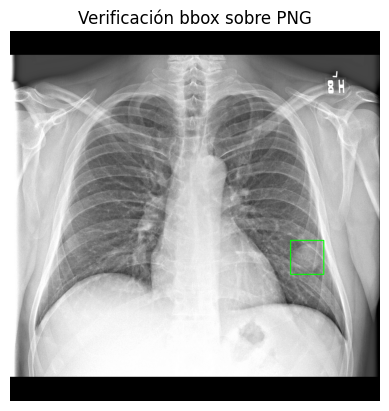

In [7]:
import cv2
import matplotlib.pyplot as plt

row = df[df["label"] == 1].iloc[0]
img = cv2.imread(row["file_path"], cv2.IMREAD_GRAYSCALE)

x1 = int(row["x"])
y1 = int(row["y"])
x2 = int(x1 + row["width"])
y2 = int(y1 + row["height"])

img_dbg = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.rectangle(img_dbg, (x1, y1), (x2, y2), (0,255,0), 2)

plt.imshow(img_dbg)
plt.axis("off")
plt.title("Verificación bbox sobre PNG")
plt.show()

In [ ]:
!pip install albumentations==1.3.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.8
    Uninstalling albumentations-2.0.8:
      Successfully uninstalled albumentations-2.0.8


### Augmentació d’imatges amb Albumentations (amb bboxes)
Aquest bloc defineix un pipeline d’augmentació per fer el model més robust, aplicant transformacions aleatòries a les imatges **i actualitzant les bounding boxes** de forma coherent.

Inclou:
- **Flip horitzontal** (`p=0.5`)
- **Canvis de brillantor i contrast** (`p=0.3`)
- **Transformacions afins** (traslació, escala i rotació) (`p=0.5`)

A més, `bbox_params` indica que:
- Les bboxes estan en format **Pascal VOC** (`[x1, y1, x2, y2]`)
- Les etiquetes van a `class_labels`
- Es descarten bboxes que quedin massa poc visibles (`min_visibility=0.3`)


In [12]:
import albumentations as A

augment = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.Affine(
            translate_percent=0.05,
            scale=(0.9, 1.1),
            rotate=(-10, 10),
            p=0.5
        ),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["class_labels"],
        min_visibility=0.3
    )
)


### Generació de mostres augmentades (només positius) amb actualització de bboxes
Aquest codi recorre totes les files del `df` amb **label = 1** (imatges amb nòdul) i genera **2 augmentacions per cada cas** utilitzant el pipeline `augment`.

Per cada imatge:
- Llegeix el PNG original (`cv2.imread`)
- Converteix la bbox del CSV a format **Pascal VOC** (`x1,y1,x2,y2`)
- Aplica l’augmentació i recupera la nova bbox transformada
- Descarta augmentacions sense bbox o amb bbox massa petita
- Guarda la imatge augmentada en disc (`cv2.imwrite`)
- Afegeix una nova fila (`aug_rows`) amb el nou nom i les noves coordenades (`x,y,width,height`)

Això permet **augmentar el nombre de positius** de forma controlada i mantenint les anotacions correctes.


In [32]:
aug_rows = []
AUG_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images"

for _, row in df[df["label"] == 1].iterrows():

    img = cv2.imread(row["file_path"])
    if img is None:
        continue

    x1 = row["x"]
    y1 = row["y"]
    x2 = x1 + row["width"]
    y2 = y1 + row["height"]

    bboxes = [(x1, y1, x2, y2)]
    labels = [1]

    for k in range(2):
        augmented = augment(image=img, bboxes=bboxes, class_labels=labels)

        if len(augmented["bboxes"]) == 0:
            continue

        img_aug = augmented["image"]
        x1a, y1a, x2a, y2a = augmented["bboxes"][0]

        h, w = img_aug.shape[:2]
        x1a = max(0, min(x1a, w-1))
        y1a = max(0, min(y1a, h-1))
        x2a = max(0, min(x2a, w-1))
        y2a = max(0, min(y2a, h-1))

        if (x2a - x1a) < 2 or (y2a - y1a) < 2:
            continue

        new_name = row["img_name"].replace(".mha", f"_aug{k}.png")
        new_path = f"{AUG_PATH}/{new_name}"

        cv2.imwrite(new_path, img_aug)

        aug_rows.append({
            "img_name": new_name,
            "label": 1,
            "x": x1a,
            "y": y1a,
            "width": x2a - x1a,
            "height": y2a - y1a,
            "file_path": new_path
        })

### Creació del CSV final amb dades augmentades
Aquest bloc converteix `aug_rows` en un DataFrame (`df_aug`) i el concatena amb el metadata original (`df`) per generar un nou dataset ampliat (`df_final`).

Finalment:
- Guarda el nou CSV complet a `metadata_augmented_def2.csv`
- Mostra el recompte d’exemples totals, originals i augmentats

Això permet entrenar amb un conjunt **més gran** i amb **més casos positius** gràcies a l’augmentació.


In [33]:
df_aug = pd.DataFrame(aug_rows)
df_final = pd.concat([df, df_aug], ignore_index=True)
OUT_CSV = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv"
df_final.to_csv(OUT_CSV, index=False)

print("CSV final guardado en:", OUT_CSV)
print("Total imágenes:", len(df_final))
print("Originales:", len(df))
print("Aumentadas:", len(df_aug))

CSV final guardado en: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv
Total imágenes: 8175
Originales: 5224
Aumentadas: 2951


### Comprovació del CSV augmentat (metadata_augmented_def2.csv)
Aquest codi carrega el CSV final amb augmentació i imprimeix:

- El **nombre total de files** (anotacions) del fitxer
- Quantes corresponen a imatges **augmentades**, detectant-les pel text `"_aug"` dins `img_name`

Així verifies ràpidament que l’augmentació s’ha afegit correctament al metadata.


In [34]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt

CSV_AUG = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv"
df_aug = pd.read_csv(CSV_AUG)

print("Total files al CSV:", len(df_aug))
print("Augmentades:", df_aug["img_name"].str.contains("_aug").sum())

Total files al CSV: 8175
Augmentades: 2951


### Visualització comparativa: imatge original vs imatge augmentada (amb bbox)
Aquest fragment serveix per **validar visualment que l’augmentació ha actualitzat correctament la bounding box**.

Fa el següent:

- Carrega la **imatge augmentada** i hi dibuixa la seva bbox (`x,y,width,height`)
- Intenta **deduir el nom i la ruta de la imatge original** eliminant `"_aug"` del nom
- Si troba l’original, recupera la seva bbox del CSV i també la dibuixa
- Mostra les dues imatges en paral·lel (*original* i *augmentada*) per comparar-les fàcilment


/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0080.png


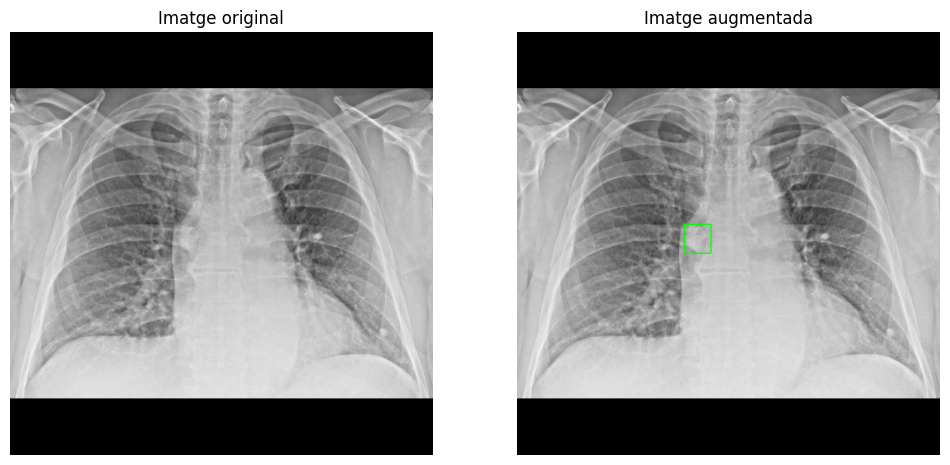

In [36]:
import cv2
import matplotlib.pyplot as plt
import os

# --- Imagen augmentada ---
img_aug = cv2.imread(row["file_path"])
assert img_aug is not None, "No s'ha pogut carregar la imatge augmentada"

x1 = int(row["x"])
y1 = int(row["y"])
x2 = int(x1 + row["width"])
y2 = int(y1 + row["height"])

img_aug_vis = img_aug.copy()
cv2.rectangle(img_aug_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

# --- Intentar localizar la imagen original ---
orig_name = row["img_name"].split("_aug")[0] + ".png"
orig_path = row["file_path"].replace("images_aug", "images1").replace(row["img_name"], orig_name)
print(orig_path)

img_orig_vis = None

if os.path.exists(orig_path):
    img_orig = cv2.imread(orig_path)
    if img_orig is not None:
        # Buscar bbox original en el CSV
        df_orig = df_aug[df_aug["img_name"] == orig_name]
        if len(df_orig) > 0:
            r = df_orig.iloc[0]
            xo1 = int(r["x"])
            yo1 = int(r["y"])
            xo2 = int(xo1 + r["width"])
            yo2 = int(yo1 + r["height"])

            img_orig_vis = img_orig.copy()
            cv2.rectangle(img_orig_vis, (xo1, yo1), (xo2, yo2), (0, 255, 0), 2)
        else:
            img_orig_vis = img_orig
else:
    print("No s'ha trobat la imatge original")

# --- Visualización ---
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
if img_orig_vis is not None:
    plt.imshow(cv2.cvtColor(img_orig_vis, cv2.COLOR_BGR2RGB))
    plt.title("Imatge original")
else:
    plt.text(0.5, 0.5, "Original no disponible", ha="center", va="center")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_aug_vis, cv2.COLOR_BGR2RGB))
plt.title("Imatge augmentada")
plt.axis("off")

plt.show()
